Лабораторная работа №1. Анализ и прогнозирование продаж

В данных 48 месяцев продаж, с 2020 по 2023 год. Для обучения использую 2020–2022 годы, из них последние 6 месяцев оставляю для подбора параметров. На 2023 годе проверю готовые модели.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 5)

2.1. Разведочный анализ данных

In [2]:
data_path = "dataset/retail_sales_mock_data.csv"
df = pd.read_csv(data_path, parse_dates=["Date"], index_col="Date")

print("Пропуски:", df.isna().sum().sum())
print("Повторяющиеся даты:", df.index.duplicated().sum())
dates = pd.date_range(df.index.min(), df.index.max(), freq="MS")
print("Пропущенные месяцы:", len(dates.difference(df.index)))
df = df.sort_index().asfreq("MS")

train = df.loc["2020":"2022"]
test = df.loc["2023"]
fit = train.iloc[:-6]
validation = train.iloc[-6:]
y = train["SalesAmount"]
exog_cols = ["Promotion", "HolidayMonth"]

print("Обучение:", len(fit), "; проверка:", len(validation), "; тест:", len(test))
display(train.head())
display(train.tail())
display(train.describe().round(2))
display(train.groupby(train.index.month)["SalesAmount"].agg(["mean", "std"]).round(2))
display(train.groupby(exog_cols)["SalesAmount"].agg(["count", "mean"]).round(2))

Пропуски: 0
Повторяющиеся даты: 0
Пропущенные месяцы: 0
Обучение: 30 ; проверка: 6 ; тест: 12


,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


,SalesAmount,Promotion,HolidayMonth
Date,,,
2022-08-01,12043,0,0
2022-09-01,11892,0,0
2022-10-01,11121,0,0
2022-11-01,11812,0,0
2022-12-01,15645,0,1


,SalesAmount,Promotion,HolidayMonth
count,36.00,36.00,36.00
mean,11511.86,0.14,0.08
std,2233.19,0.35,0.28
min,7783.00,0.00,0.00
25%,9929.25,0.00,0.00
50%,11674.50,0.00,0.00
75%,12795.75,0.00,0.00
max,16623.00,1.00,1.00


,mean,std
Date,,
1,13863.67,2401.28
2,13357.00,859.90
3,12627.00,451.07
4,12011.67,1827.82
5,8954.00,1255.11
6,8460.00,599.78
7,8911.00,407.30
8,10717.67,1173.63
9,11462.33,867.37


count      mean
Promotion HolidayMonth                 
0         0                28  10917.96
          1                 3  14958.33
1         0                 5  12769.80

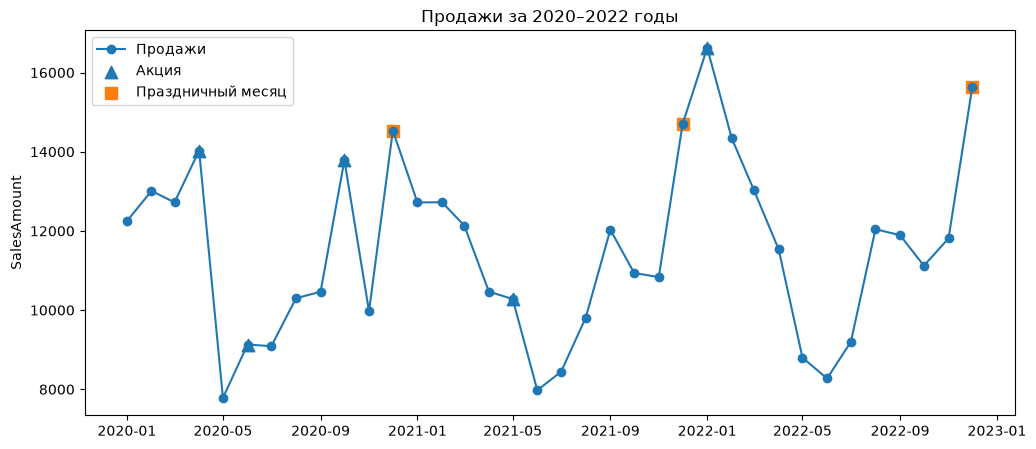

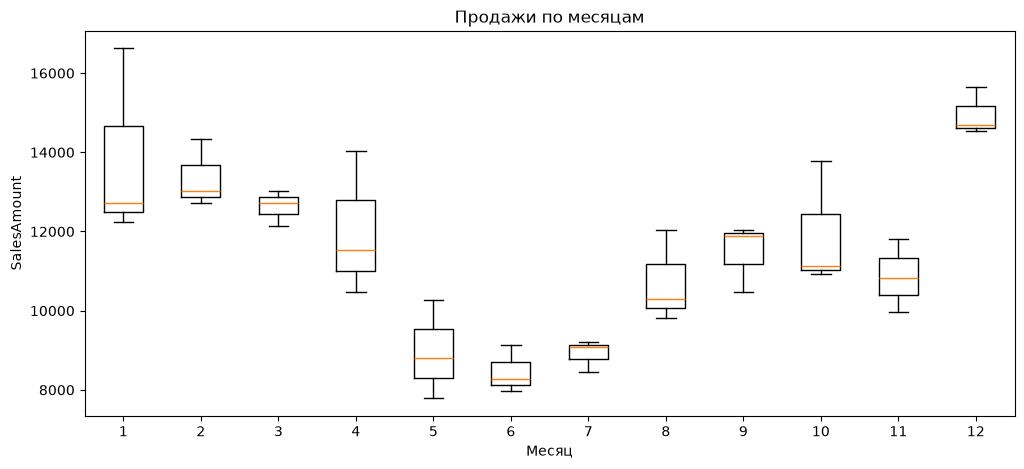

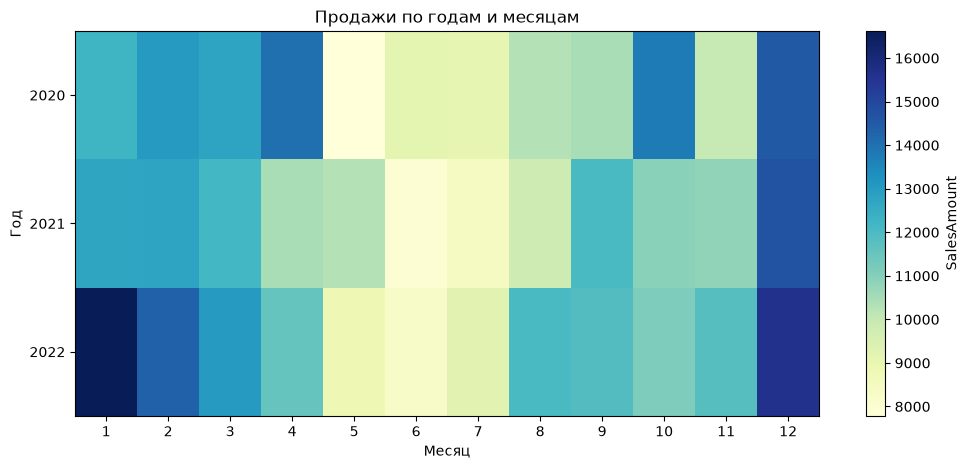

In [3]:
plt.plot(train.index, y, marker="o", label="Продажи")
plt.scatter(train.index[train.Promotion == 1], y[train.Promotion == 1],
            marker="^", s=80, label="Акция")
plt.scatter(train.index[train.HolidayMonth == 1], y[train.HolidayMonth == 1],
            marker="s", s=80, label="Праздничный месяц")
plt.title("Продажи за 2020–2022 годы")
plt.ylabel("SalesAmount")
plt.legend()
plt.show()

months = [y[y.index.month == i] for i in range(1, 13)]
plt.boxplot(months, tick_labels=range(1, 13))
plt.xlabel("Месяц")
plt.ylabel("SalesAmount")
plt.title("Продажи по месяцам")
plt.show()

table = train.copy()
table["Year"] = table.index.year
table["Month"] = table.index.month
heatmap = table.pivot(index="Year", columns="Month", values="SalesAmount")
plt.imshow(heatmap, aspect="auto", cmap="YlGnBu")
plt.xticks(range(12), range(1, 13))
plt.yticks(range(len(heatmap)), heatmap.index)
plt.xlabel("Месяц")
plt.ylabel("Год")
plt.title("Продажи по годам и месяцам")
plt.colorbar(label="SalesAmount")
plt.show()

Пропусков и повторяющихся дат нет. Зимой продажи в основном выше, летом ниже. В декабре средние продажи около 15 тыс., в июне — около 8,5 тыс. На каждый месяц есть только три наблюдения, поэтому сравнение довольно грубое. Месяцев с акциями всего пять, и по одним средним нельзя отделить эффект акции от сезонности.

Декомпозиция и STL

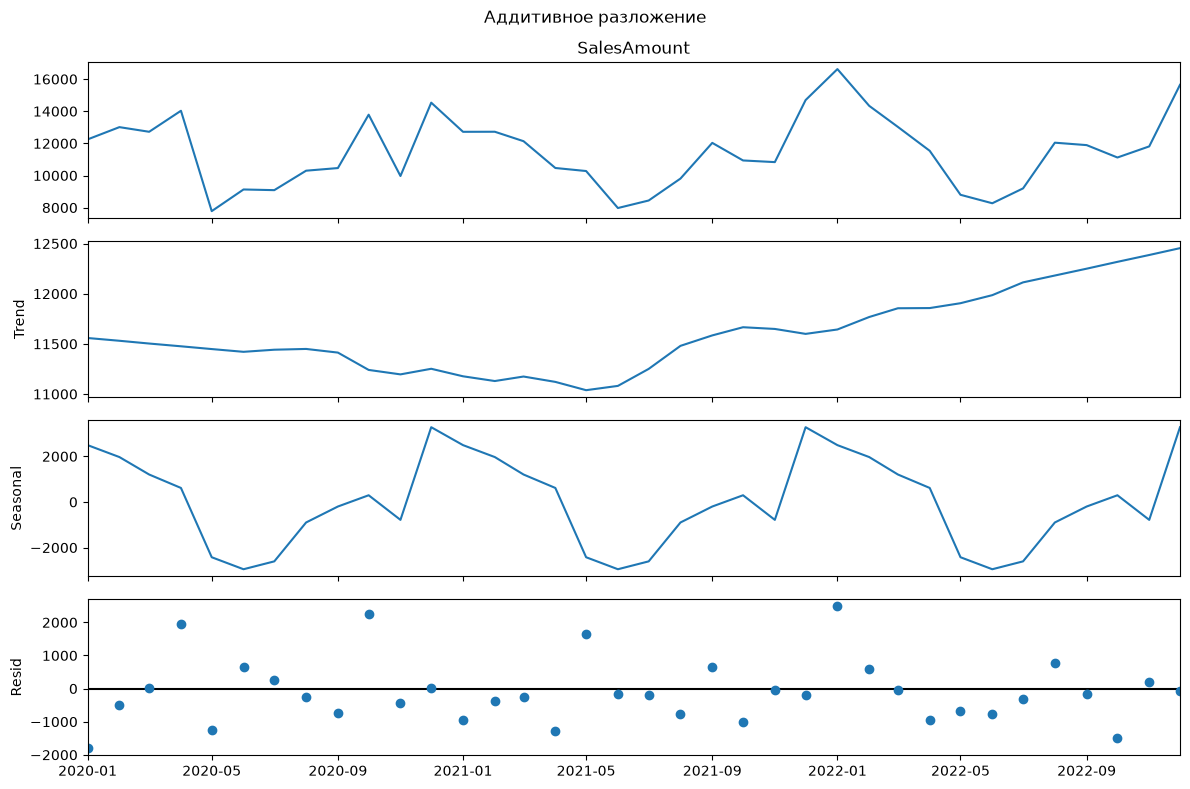

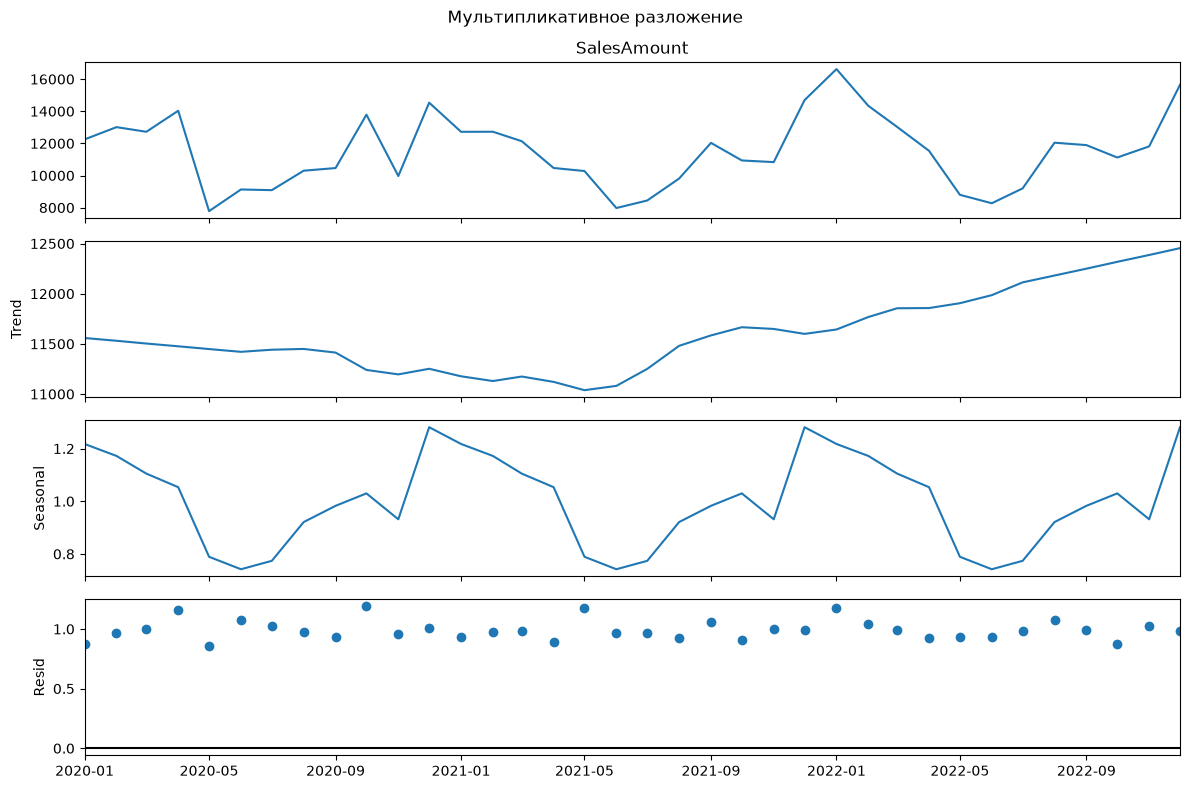

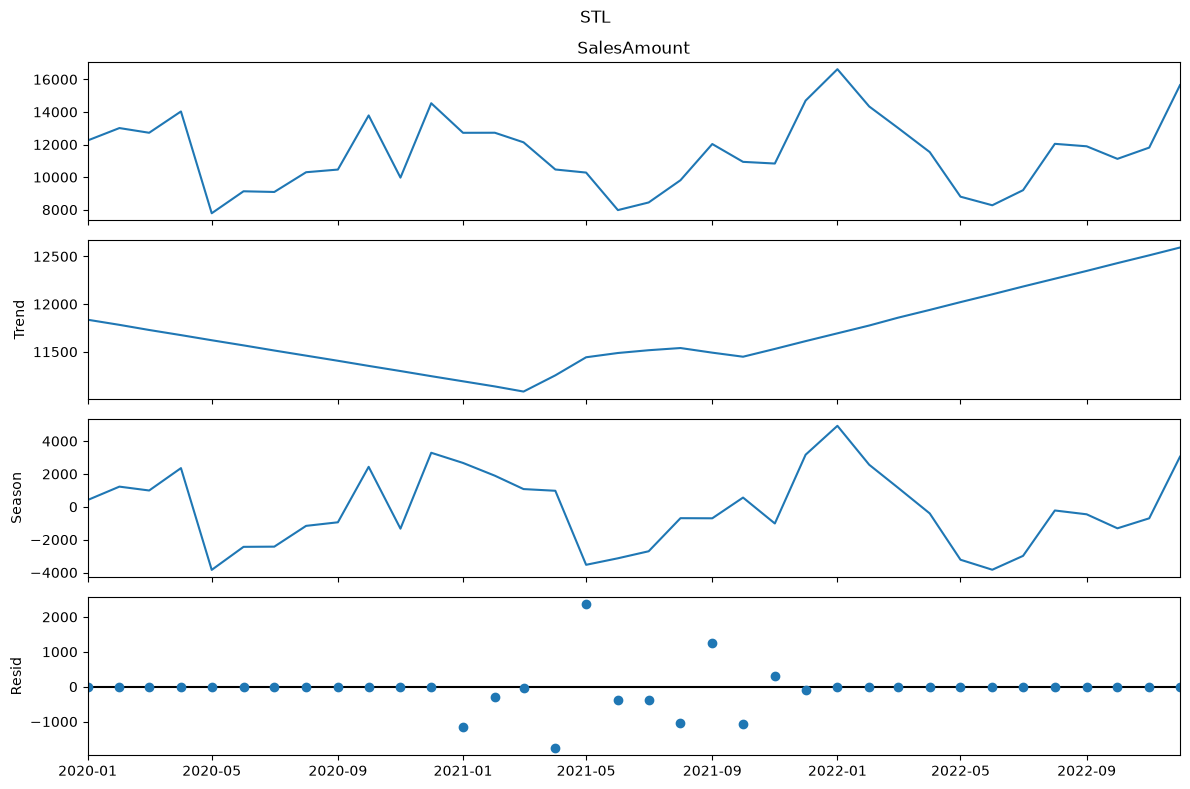

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL

additive = seasonal_decompose(y, model="additive", period=12, extrapolate_trend=12)
multiplicative = seasonal_decompose(y, model="multiplicative", period=12, extrapolate_trend=12)
stl = STL(y, period=12, seasonal=13, robust=True).fit()

additive.plot()
plt.gcf().set_size_inches(12, 8)
plt.suptitle("Аддитивное разложение")
plt.tight_layout()
plt.show()

multiplicative.plot()
plt.gcf().set_size_inches(12, 8)
plt.suptitle("Мультипликативное разложение")
plt.tight_layout()
plt.show()

stl.plot()
plt.gcf().set_size_inches(12, 8)
plt.suptitle("STL")
plt.tight_layout()
plt.show()

Во всех трёх разложениях видна похожая сезонность: подъём зимой и спад летом. Общий уровень продаж немного меняется, но сезонные колебания заметнее. В остатках есть скачки, особенно у классического разложения, то есть трендом и сезонностью весь ряд не объясняется.

FFT

,Период,Амплитуда
1,12.00,2444.62
16,2.00,776.15
4,6.00,750.17
7,4.00,716.32
8,3.60,682.51
15,2.12,665.10
10,3.00,544.47
3,7.20,533.56


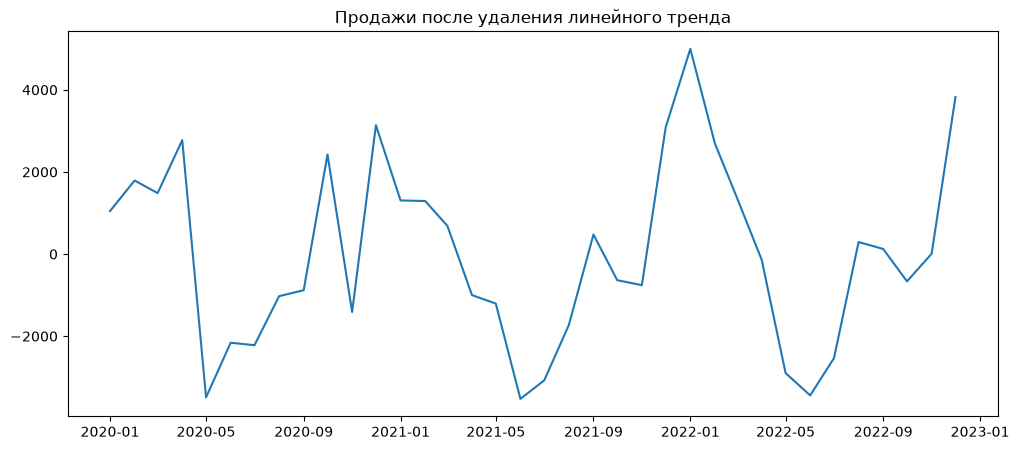

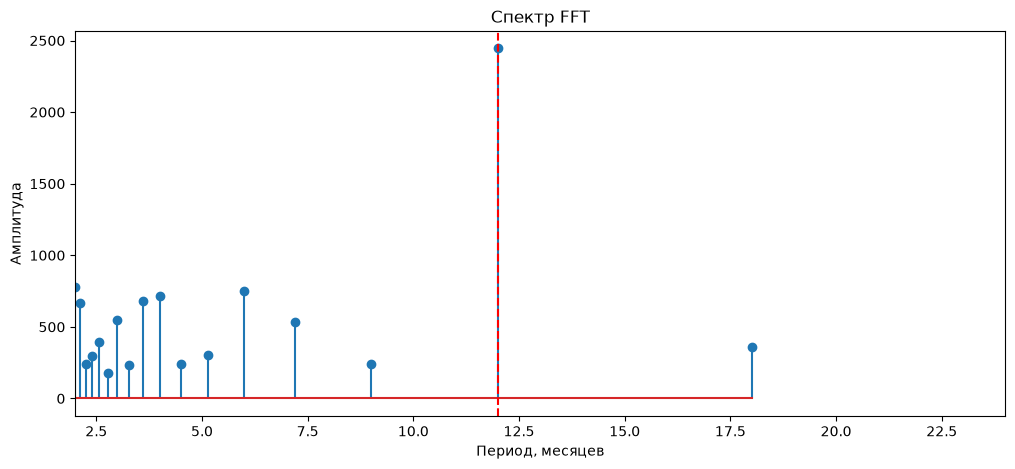

In [5]:
import numpy as np
from scipy.signal import detrend

detrended = detrend(y)
freq = np.fft.rfftfreq(len(y))
amplitude = 2 * np.abs(np.fft.rfft(detrended)) / len(y)
mask = (freq >= 1 / 24) & (freq <= 1 / 2)
fft_table = pd.DataFrame({"Период": 1 / freq[mask], "Амплитуда": amplitude[mask]})
fft_table = fft_table.sort_values("Амплитуда", ascending=False)
display(fft_table.head(8).round(2))

plt.plot(y.index, detrended)
plt.title("Продажи после удаления линейного тренда")
plt.show()

plt.stem(fft_table["Период"], fft_table["Амплитуда"])
plt.axvline(12, color="red", linestyle="--")
plt.xlim(2, 24)
plt.xlabel("Период, месяцев")
plt.ylabel("Амплитуда")
plt.title("Спектр FFT")
plt.show()

Самый сильный пик получился на 12 месяцах, амплитуда около 2445. Остальные пики намного ниже. Годовая сезонность, которую было видно на графиках, подтвердилась.

Вейвлет-анализ

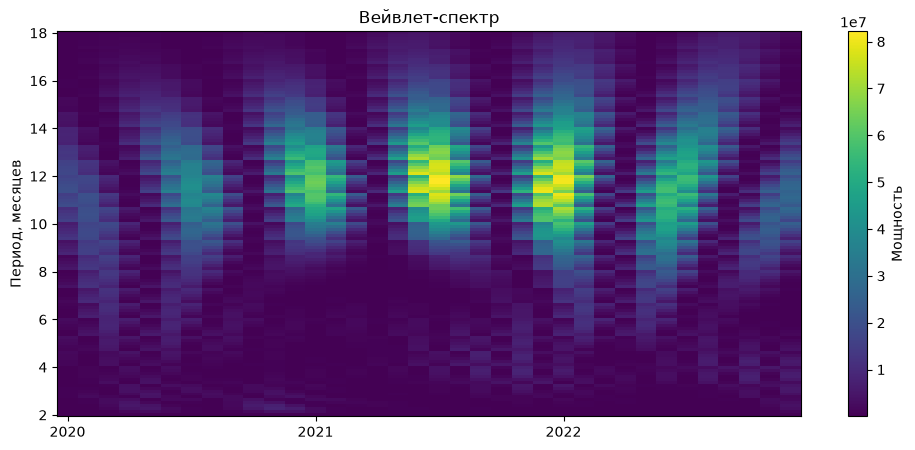

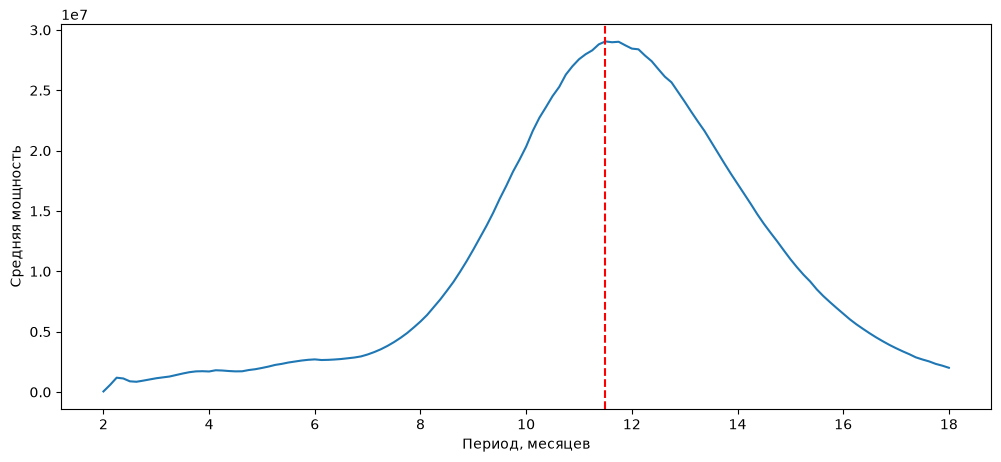

Период по вейвлетам: 11.5 месяца


In [6]:
import pywt

periods = np.linspace(2, 18, 129)
scales = pywt.central_frequency("morl") * periods
coef, wavelet_freq = pywt.cwt(detrended, scales, "morl", sampling_period=1)
wavelet_periods = 1 / wavelet_freq
power = np.abs(coef) ** 2
mean_power = power.mean(axis=1)
wavelet_peak = wavelet_periods[mean_power.argmax()]

plt.pcolormesh(range(len(y)), wavelet_periods, power, shading="auto")
plt.xticks(range(0, len(y), 12), y.index[::12].year)
plt.ylabel("Период, месяцев")
plt.title("Вейвлет-спектр")
plt.colorbar(label="Мощность")
plt.show()

plt.plot(wavelet_periods, mean_power)
plt.axvline(wavelet_peak, color="red", linestyle="--")
plt.xlabel("Период, месяцев")
plt.ylabel("Средняя мощность")
plt.show()

print("Период по вейвлетам:", round(wavelet_peak, 2), "месяца")

По вейвлетам основной период около 11,5 месяца, что близко к результату FFT. Сильнее всего выделяется область около года. На краях ряда картина менее надёжная, потому что данных мало. Для сезонной модели дальше беру период 12.

Стационарность, ACF и PACF

,Ряд,N,ADF p-value,KPSS p-value
0,Исходный,36,0.003,0.1
1,Первая разность,35,0.000,0.1
2,Сезонная разность,24,0.508,0.1
3,Первая + сезонная,23,0.578,0.1


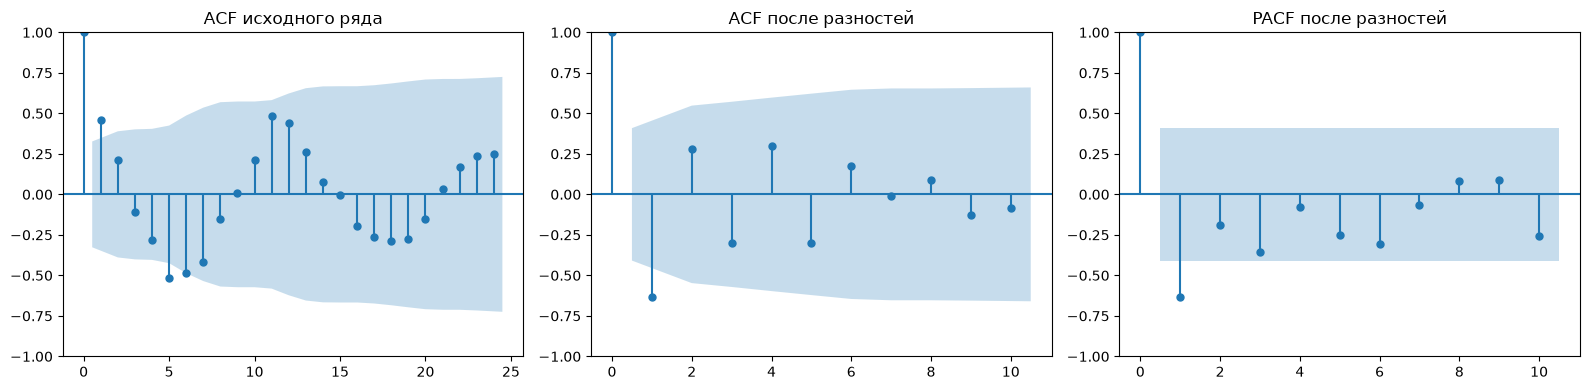

In [7]:
import warnings
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")

variants = {
    "Исходный": y,
    "Первая разность": y.diff().dropna(),
    "Сезонная разность": y.diff(12).dropna(),
    "Первая + сезонная": y.diff().diff(12).dropna()
}
rows = []
for name, values in variants.items():
    adf_p = adfuller(values, autolag="AIC")[1]
    kpss_p = kpss(values, regression="c", nlags="auto")[1]
    rows.append([name, len(values), adf_p, kpss_p])

stationarity = pd.DataFrame(rows, columns=["Ряд", "N", "ADF p-value", "KPSS p-value"])
display(stationarity.round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_acf(y, lags=24, ax=axes[0])
plot_acf(variants["Первая + сезонная"], lags=10, ax=axes[1])
plot_pacf(variants["Первая + сезонная"], lags=10, ax=axes[2], method="ywm")
axes[0].set_title("ACF исходного ряда")
axes[1].set_title("ACF после разностей")
axes[2].set_title("PACF после разностей")
plt.tight_layout()
plt.show()

У исходного ряда ADF p-value около 0,003, а KPSS не отвергает стационарность: его p-value не меньше 0,1. После сезонной разности ADF уже не даёт такого результата. На коротком ряде проверки получились неоднозначными, поэтому число разностей выберу по качеству прогноза. Годовая связь на ACF при этом заметна.

2.2. Подбор ARIMA и SARIMAX

In [8]:
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

arima_orders = [(0, 0, 0), (1, 0, 0), (0, 0, 1), (1, 0, 1),
                (0, 1, 0), (1, 1, 0), (0, 1, 1), (1, 1, 1)]
sarimax_orders = [(0, 1, 0), (1, 1, 0), (2, 1, 0), (1, 1, 1)]
seasonal_order = (1, 1, 0, 12)
rows = []

for order in arima_orders:
    model = ARIMA(fit.SalesAmount, order=order).fit()
    result = ARIMA(train.SalesAmount, order=order).fit()
    forecast = model.forecast(len(validation))
    rows.append(["ARIMA", order, None,
                 mean_squared_error(validation.SalesAmount, forecast),
                 result.aic, result.bic,
                 len(train) - result.model.loglikelihood_burn,
                 model.mle_retvals["converged"] and result.mle_retvals["converged"]])

for order in sarimax_orders:
    model = SARIMAX(fit.SalesAmount, exog=fit[exog_cols], order=order,
                    seasonal_order=seasonal_order, enforce_stationarity=False,
                    enforce_invertibility=False).fit(disp=False, maxiter=100)
    result = SARIMAX(train.SalesAmount, exog=train[exog_cols], order=order,
                     seasonal_order=seasonal_order, enforce_stationarity=False,
                     enforce_invertibility=False).fit(disp=False, maxiter=100)
    forecast = model.forecast(len(validation), exog=validation[exog_cols])
    rows.append(["SARIMAX", order, seasonal_order,
                 mean_squared_error(validation.SalesAmount, forecast),
                 result.aic, result.bic,
                 len(train) - result.model.loglikelihood_burn,
                 model.mle_retvals["converged"] and result.mle_retvals["converged"]])

search_results = pd.DataFrame(rows, columns=["Model", "Order", "Seasonal_order",
                                           "Validation_MSE", "AIC", "BIC",
                                           "Likelihood_N", "Converged"])
display(search_results.sort_values(["Model", "Validation_MSE"]).round(3))

usable = search_results[search_results["Converged"]]
best_arima = usable[usable["Model"] == "ARIMA"].sort_values("Validation_MSE").iloc[0]
best_sarimax = usable[usable["Model"] == "SARIMAX"].sort_values("Validation_MSE").iloc[0]
arima_order = best_arima["Order"]
sarimax_order = best_sarimax["Order"]
display(pd.DataFrame([best_arima, best_sarimax]).round(3))

,Model,Order,Seasonal_order,Validation_MSE,AIC,BIC,Likelihood_N,Converged
2,ARIMA,"(0, 0, 1)",None,3.449165e+06,655.633,660.384,36,True
1,ARIMA,"(1, 0, 0)",None,3.599213e+06,653.070,657.821,36,True
3,ARIMA,"(1, 0, 1)",None,3.623204e+06,655.149,661.484,36,True
0,ARIMA,"(0, 0, 0)",None,3.935510e+06,660.355,663.522,36,True
6,ARIMA,"(0, 1, 1)",None,1.642580e+07,642.352,645.463,35,True
5,ARIMA,"(1, 1, 0)",None,1.675392e+07,641.851,644.961,35,True
4,ARIMA,"(0, 1, 0)",None,1.719159e+07,640.478,642.033,35,True
7,ARIMA,"(1, 1, 1)",None,1.722133e+07,643.803,648.469,35,True
9,SARIMAX,"(1, 1, 0)","(1, 1, 0, 12)",4.871624e+05,167.546,169.059,10,True
10,SARIMAX,"(2, 1, 0)","(1, 1, 0, 12)",5.499699e+05,147.388,148.571,9,True


,Model,Order,Seasonal_order,Validation_MSE,AIC,BIC,Likelihood_N,Converged
2,ARIMA,"(0, 0, 1)",None,3449165.411,655.633,660.384,36,True
9,SARIMAX,"(1, 1, 0)","(1, 1, 0, 12)",487162.375,167.546,169.059,10,True


На шести месяцах проверки лучше всего получились ARIMA(0,0,1) и SARIMAX(1,1,0) с сезонной частью (1,1,0,12). MSE у SARIMAX около 487 тыс., у ARIMA — 3,45 млн. Самый низкий AIC у другого варианта SARIMAX, но у него ошибка прогноза выше и меньше наблюдений в расчёте правдоподобия. Поэтому оставляю вариант с меньшей MSE.

2.3. Прогноз и сравнение качества

,Test_MSE,Test_R2,Train_AIC,Train_BIC,Likelihood_N
Model,,,,,
Seasonal_naive,2757115.250,0.404,NaN,NaN,NaN
ARIMA,5274415.275,-0.140,655.633,660.384,36.0
SARIMAX,538540.585,0.884,167.546,169.059,10.0


,Actual,Seasonal_naive,ARIMA,SARIMAX
Date,,,,
2023-01-01,13904,16623,12972.78,14098.60
2023-02-01,13901,14336,11511.86,14475.66
2023-03-01,13534,13023,11511.86,13773.87
2023-04-01,12048,11537,11511.86,12065.17
2023-05-01,12949,8800,11511.86,12454.53
2023-06-01,9104,8273,11511.86,9308.35
2023-07-01,10042,9199,11511.86,9983.97
2023-08-01,11566,12043,11511.86,11875.47
2023-09-01,11759,11892,11511.86,13229.24


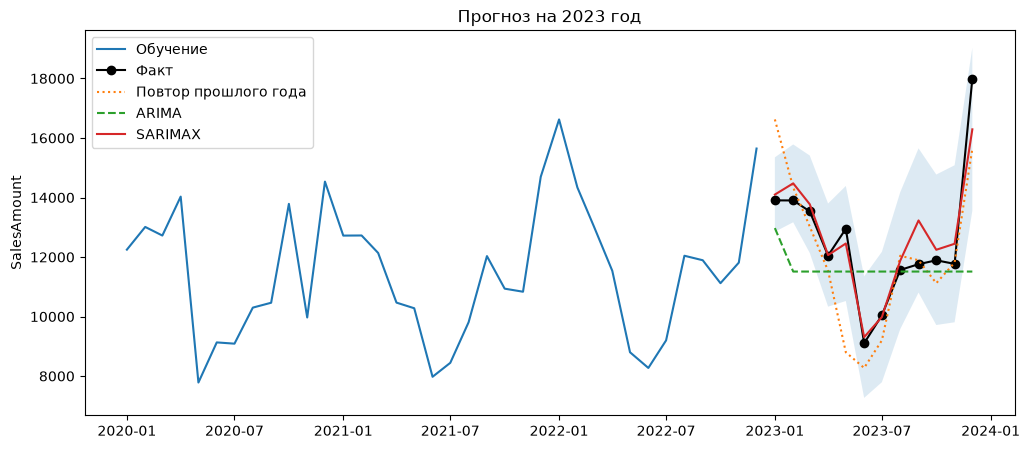

In [9]:
arima_result = ARIMA(train.SalesAmount, order=arima_order).fit()
sarimax_result = SARIMAX(train.SalesAmount, exog=train[exog_cols], order=sarimax_order,
                         seasonal_order=seasonal_order, enforce_stationarity=False,
                         enforce_invertibility=False).fit(disp=False, maxiter=100)

arima_forecast = arima_result.get_forecast(steps=len(test))
sarimax_forecast = sarimax_result.get_forecast(steps=len(test), exog=test[exog_cols])
predictions = pd.DataFrame(index=test.index)
predictions["Actual"] = test.SalesAmount
# Для сравнения просто повторяю продажи тех же месяцев прошлого года.
predictions["Seasonal_naive"] = train.SalesAmount.iloc[-12:].values
predictions["ARIMA"] = arima_forecast.predicted_mean
predictions["SARIMAX"] = sarimax_forecast.predicted_mean

rows = []
for name in ["Seasonal_naive", "ARIMA", "SARIMAX"]:
    rows.append([name, mean_squared_error(predictions.Actual, predictions[name]),
                 r2_score(predictions.Actual, predictions[name])])
comparison = pd.DataFrame(rows, columns=["Model", "Test_MSE", "Test_R2"]).set_index("Model")
for name, result in [("ARIMA", arima_result), ("SARIMAX", sarimax_result)]:
    comparison.loc[name, "Train_AIC"] = result.aic
    comparison.loc[name, "Train_BIC"] = result.bic
    comparison.loc[name, "Likelihood_N"] = len(train) - result.model.loglikelihood_burn
display(comparison.round(3))
display(predictions.round(2))

plt.plot(train.index, train.SalesAmount, label="Обучение")
plt.plot(test.index, test.SalesAmount, label="Факт", color="black", marker="o")
plt.plot(test.index, predictions.Seasonal_naive, label="Повтор прошлого года", linestyle=":")
plt.plot(test.index, predictions.ARIMA, label="ARIMA", linestyle="--")
plt.plot(test.index, predictions.SARIMAX, label="SARIMAX")
interval = sarimax_forecast.conf_int()
plt.fill_between(test.index, interval.iloc[:, 0], interval.iloc[:, 1], alpha=0.15)
plt.title("Прогноз на 2023 год")
plt.ylabel("SalesAmount")
plt.legend()
plt.show()

На 2023 годе SARIMAX тоже оказалась лучше: MSE около 538 541, $R^2$ около 0,884. У повтора прошлого года MSE около 2 757 115 и $R^2$ около 0,404, у ARIMA — 5 274 415 и −0,140. ARIMA почти всё время предсказывает одно значение и пропускает сезонные изменения. SARIMAX передаёт их лучше, но сильно ошиблась в сентябре и недооценила декабрь.

AIC и BIC у SARIMAX ниже, но напрямую сравнивать их с ARIMA здесь нельзя: в расчёте правдоподобия осталось 10 наблюдений против 36. По прогнозу преимущество SARIMAX видно и без этих критериев. При проверке использованы фактические признаки акций и праздников 2023 года, поэтому этот результат предполагает, что они известны заранее.

Горизонт прогноза

In [10]:
rows = []
for h in range(4, len(test) + 1):
    actual = predictions.Actual.iloc[:h]
    forecast = predictions.SARIMAX.iloc[:h]
    naive = predictions.Seasonal_naive.iloc[:h]
    mse = mean_squared_error(actual, forecast)
    naive_mse = mean_squared_error(actual, naive)
    r2 = r2_score(actual, forecast)
    rows.append([h, mse, naive_mse, r2, mse < naive_mse and r2 > 0])

horizon_table = pd.DataFrame(rows, columns=["Horizon_months", "SARIMAX_MSE",
                                          "Seasonal_naive_MSE", "SARIMAX_R2", "Acceptable"])
display(horizon_table.round(3))
max_horizon = int(horizon_table.loc[horizon_table["Acceptable"], "Horizon_months"].max())
print("Максимальный проверенный горизонт:", max_horizon, "месяцев")

,Horizon_months,SARIMAX_MSE,Seasonal_naive_MSE,SARIMAX_R2,Acceptable
0,4,106484.715,2026107.000,0.818,True
1,5,134088.012,5063725.800,0.728,True
2,6,118699.503,4334865.000,0.958,True
3,7,102223.494,3817119.857,0.968,True
4,8,101416.652,3368421.000,0.964,True
5,9,330325.102,2996117.444,0.870,True
6,10,309798.349,2755641.800,0.865,True
7,11,323069.655,2505289.273,0.846,True
8,12,538540.585,2757115.250,0.884,True


Максимальный проверенный горизонт: 12 месяцев


Для периодов от 4 до 12 месяцев MSE у SARIMAX ниже, чем у повтора прошлого года, а $R^2$ положителен. В этой проверке модель справилась с прогнозом на год. Проверка была только одна, поэтому такой же результат на следующем годе не гарантирован. Более длинный срок по этим данным оценить не получилось.

Остатки моделей

,Model,N_residuals,Ljung_Box_lag,Ljung_Box_p,Shapiro_p,Breusch_Pagan_p
0,ARIMA,35,6,0.019,0.578,0.744
1,SARIMAX,10,2,0.262,0.241,0.982


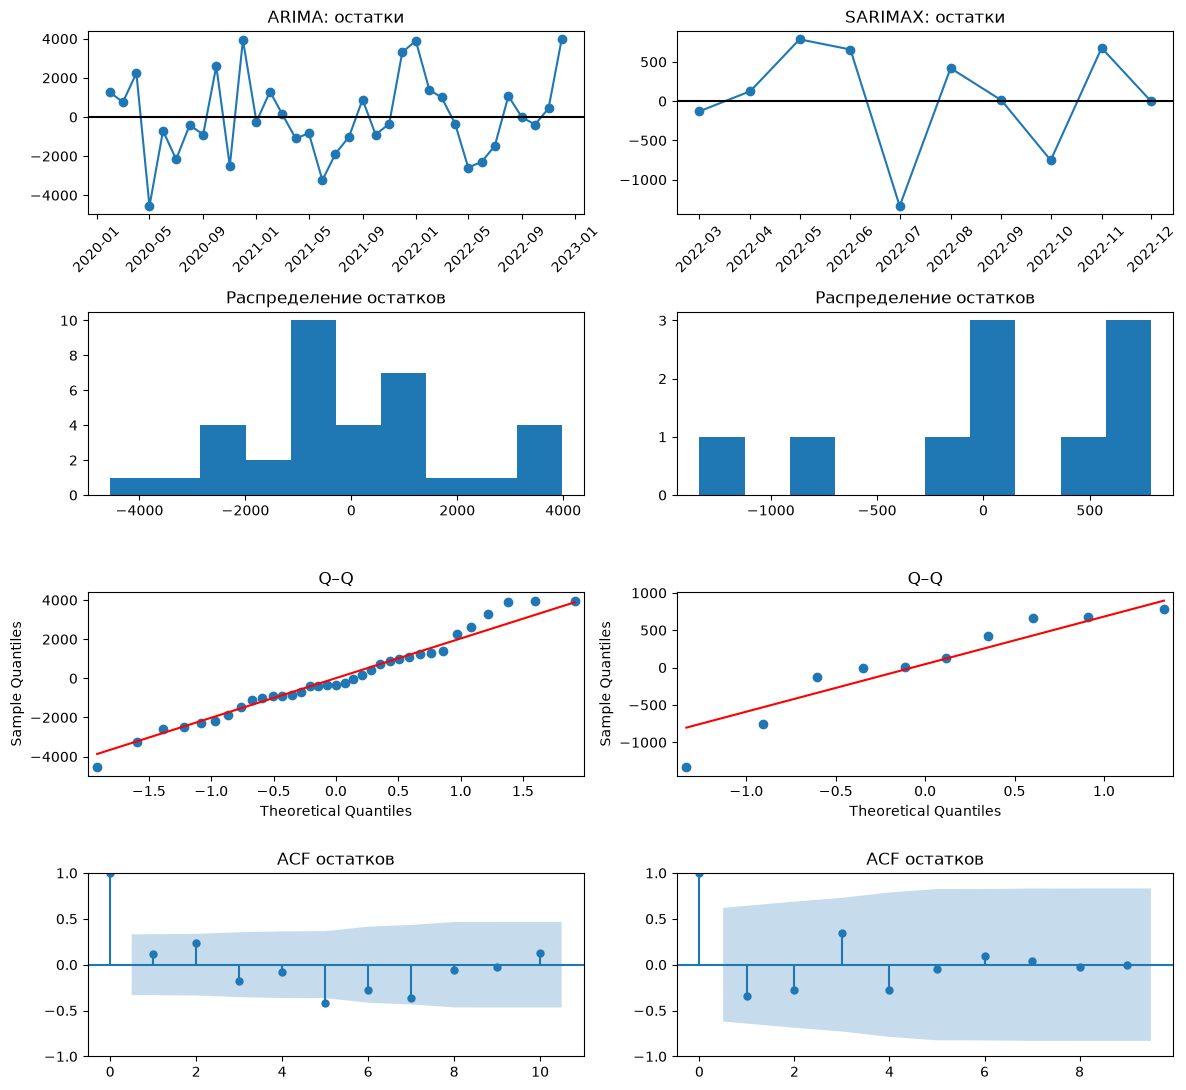

In [11]:
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.tools.tools import add_constant
from statsmodels.graphics.gofplots import qqplot

residuals = {}
rows = []
for name, result in [("ARIMA", arima_result), ("SARIMAX", sarimax_result)]:
    # Начало ряда после разностей не беру в проверку остатков.
    skip = max(result.model.loglikelihood_burn, 1)
    errors = result.resid.iloc[skip:].dropna()
    residuals[name] = errors
    lag = min(6, len(errors) // 4)
    lb_p = acorr_ljungbox(errors, lags=[lag]).lb_pvalue.iloc[0]
    shapiro_p = shapiro(errors).pvalue
    bp_p = het_breuschpagan(errors, add_constant(np.arange(len(errors))))[1]
    rows.append([name, len(errors), lag, lb_p, shapiro_p, bp_p])

diagnostics = pd.DataFrame(rows, columns=["Model", "N_residuals", "Ljung_Box_lag",
                                        "Ljung_Box_p", "Shapiro_p", "Breusch_Pagan_p"])
display(diagnostics.round(3))

fig, axes = plt.subplots(4, 2, figsize=(12, 11))
for i, (name, errors) in enumerate(residuals.items()):
    axes[0, i].plot(errors.index, errors, marker="o")
    axes[0, i].axhline(0, color="black")
    axes[0, i].set_title(name + ": остатки")
    axes[0, i].tick_params(axis="x", labelrotation=45)
    axes[1, i].hist(errors, bins=10)
    axes[1, i].set_title("Распределение остатков")
    qqplot(errors, line="s", ax=axes[2, i])
    axes[2, i].set_title("Q–Q")
    plot_acf(errors, lags=min(10, len(errors) - 1), ax=axes[3, i])
    axes[3, i].set_title("ACF остатков")
plt.tight_layout()
plt.show()

У ARIMA тест Льюнга–Бокса дал p-value около 0,019: в остатках осталась автокорреляция. У SARIMAX p-value около 0,262, такой проблемы тест не выявил. Шапиро–Уилк и Бройш–Паган тоже не дали малых p-value. Но у SARIMAX после исключения начального участка осталось всего 10 остатков, поэтому уверенно судить по этим тестам трудно. Бройш–Паган здесь проверял только изменение разброса со временем.

Прогноз на 2024 год

,Promotion,HolidayMonth,Forecast,Lower_95,Upper_95
2024-01-01,0,0,14521.07,13084.92,15957.22
2024-02-01,0,0,16455.57,14936.37,17974.77
2024-03-01,0,0,14914.01,13031.54,16796.47
2024-04-01,0,0,13865.71,11854.51,15876.91
2024-05-01,0,0,10674.73,8440.79,12908.66
2024-06-01,0,0,10651.52,8278.93,13024.12
2024-07-01,0,0,11460.08,8918.01,14002.15
2024-08-01,0,0,13771.20,11094.46,16447.94
2024-09-01,0,0,13727.29,10907.41,16547.16
2024-10-01,0,0,13410.06,10463.38,16356.75


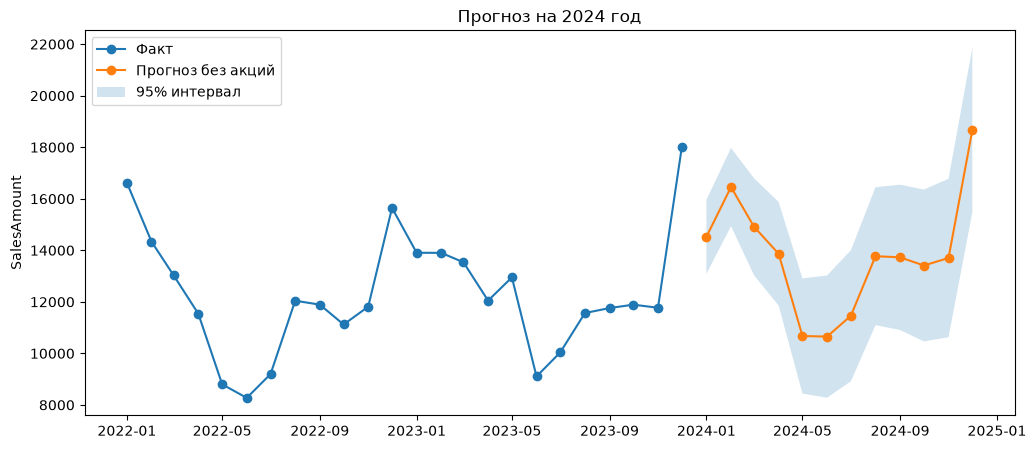

In [12]:
future_index = pd.date_range("2024-01-01", periods=max_horizon, freq="MS")
# Считаю, что акций не будет, а декабрь останется праздничным месяцем.
future_exog = pd.DataFrame({"Promotion": 0,
                           "HolidayMonth": (future_index.month == 12).astype(int)},
                          index=future_index)

full_result = SARIMAX(df.SalesAmount, exog=df[exog_cols], order=sarimax_order,
                      seasonal_order=seasonal_order, enforce_stationarity=False,
                      enforce_invertibility=False).fit(disp=False, maxiter=100)
future_result = full_result.get_forecast(steps=max_horizon, exog=future_exog)
future_interval = future_result.conf_int()
future_table = future_exog.copy()
future_table["Forecast"] = future_result.predicted_mean
future_table["Lower_95"] = future_interval.iloc[:, 0]
future_table["Upper_95"] = future_interval.iloc[:, 1]
display(future_table.round(2))

plt.plot(df.index[-24:], df.SalesAmount.iloc[-24:], label="Факт", marker="o")
plt.plot(future_index, future_table.Forecast, label="Прогноз без акций", marker="o")
plt.fill_between(future_index, future_table.Lower_95, future_table.Upper_95,
                 alpha=0.2, label="95% интервал")
plt.title("Прогноз на 2024 год")
plt.ylabel("SalesAmount")
plt.legend()
plt.show()

2.4. Вывод

В продажах есть годовая сезонность, и обычная ARIMA с ней справилась плохо. Из проверенных моделей лучше получилась SARIMAX с сезонной частью и признаками акций и праздников: на 2023 годе MSE около 539 тыс. и $R^2$ около 0,884. Она заметно лучше простого повтора прошлого года.

В прогнозе на 2024 год снова получились низкие продажи летом и высокие зимой, максимум в декабре — около 18,7 тыс. К концу года 95% интервал расширился примерно до 15,5–21,9 тыс. Это прогноз при условии, что акций не будет. Если они появятся, результат может измениться.

Для более уверенного вывода данных мало: всего четыре года и несколько месяцев с акциями. Праздничный признак совпадает с декабрём, поэтому его отдельный эффект от сезонности не отделяется. Пока модель можно считать удачной для этой проверки на год, но на новых данных её ещё надо проверить.